In [1]:
# GSCS ablation: re-score cached captions under different GDINO
# thresholds, noun extractors, and the IGNORE_WORDS filter.
# Requires the three captioning notebooks to have been run first.

!pip install -q "transformers==4.57.6" pillow accelerate nltk spacy
!python -m spacy download en_core_web_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import os
import ast
import re
import json
import zipfile
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import nltk
import spacy

from PIL import Image
from tqdm.auto import tqdm
from scipy.stats import spearmanr
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

for pkg in ["punkt", "punkt_tab", "averaged_perceptron_tagger",
            "averaged_perceptron_tagger_eng", "wordnet", "omw-1.4", "stopwords"]:
    nltk.download(pkg, quiet=True)

from nltk import word_tokenize, pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords as nltk_stopwords

nlp_spacy = spacy.load("en_core_web_sm", disable=["parser", "ner"])

print("Torch version:", torch.__version__)

Torch version: 2.9.1+cu130


In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

OUTPUTS_DIR = os.path.abspath("outputs")
BASE_DIR = os.path.join(OUTPUTS_DIR, "project_ablation")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

MODEL_CSV_PATHS = {
    "BLIP":    (os.path.join(OUTPUTS_DIR, "project_blip",         "results", "blip_full_results.csv"),    "blip_caption"),
    "ViT-GPT2":(os.path.join(OUTPUTS_DIR, "project_vitgpt2",      "results", "vitgpt2_full_results.csv"), "vitgpt2_caption"),
    "ClipCap": (os.path.join(OUTPUTS_DIR, "project_clipcap_full", "results", "clipcap_full_results.csv"), "clipcap_caption"),
}

DEFAULT_THRESHOLD = 0.35
DEFAULT_TEXT_THRESHOLD = 0.25

THRESHOLD_VARIANTS = [
    ("Strict",      0.45, 0.35),
    ("Tight*",      0.35, 0.25),   # paper default
    ("Loose",       0.25, 0.15),
    ("Permissive",  0.15, 0.10),
]

# Shared IGNORE_WORDS set used in the main notebooks
IGNORE_WORDS = {"image", "photo", "picture", "scene", "background", "front", "top", "side"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Ablation outputs dir:", BASE_DIR)

Using device: cuda
Ablation outputs dir: c:\Users\William\Desktop\Vision2Text\Vision2Text\outputs\project_ablation


In [4]:
def _safe_parse_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str) and x.startswith("["):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

frames = []
for model_name, (csv_path, caption_col) in MODEL_CSV_PATHS.items():
    if not os.path.isfile(csv_path):
        raise FileNotFoundError(
            f"Missing {csv_path}. Run the {model_name} notebook first."
        )
    df = pd.read_csv(csv_path)
    df = df[["image", "image_path", caption_col]].rename(columns={caption_col: "caption"})
    df["model"] = model_name
    frames.append(df)

captions_df = pd.concat(frames, ignore_index=True)
captions_df["caption"] = captions_df["caption"].fillna("").astype(str)
captions_df["image_path"] = captions_df["image_path"].astype(str)

per_model_counts = captions_df.groupby("model")["image"].nunique().to_dict()
shared_images = set.intersection(*[
    set(captions_df.loc[captions_df["model"] == m, "image"]) for m in MODEL_CSV_PATHS
])
captions_df = captions_df[captions_df["image"].isin(shared_images)].reset_index(drop=True)

print("Per-model image counts (pre-filter):", per_model_counts)
print("Shared images across all 3 models:", len(shared_images))
print("Unified (model x image) rows:", len(captions_df))
captions_df.head()

Per-model image counts (pre-filter): {'BLIP': 50, 'ClipCap': 50, 'ViT-GPT2': 50}
Shared images across all 3 models: 50
Unified (model x image) rows: 150


,image,image_path,caption,model
0,1000092795.jpg,c:\Users\William\Desktop\Vision2Text\Vision2Te...,a man standing in the grass,BLIP
1,10002456.jpg,c:\Users\William\Desktop\Vision2Text\Vision2Te...,the sky is white,BLIP
2,1000268201.jpg,c:\Users\William\Desktop\Vision2Text\Vision2Te...,a little girl in a pink dress,BLIP
3,1000344755.jpg,c:\Users\William\Desktop\Vision2Text\Vision2Te...,a man on a ladder,BLIP
4,1000366164.jpg,c:\Users\William\Desktop\Vision2Text\Vision2Te...,two men in the kitchen,BLIP


In [5]:
GDINO_MODEL_ID = "IDEA-Research/grounding-dino-tiny"
gdino_processor = AutoProcessor.from_pretrained(GDINO_MODEL_ID)
gdino_model = AutoModelForZeroShotObjectDetection.from_pretrained(GDINO_MODEL_ID).to(device)
gdino_model.eval()
print("Loaded Grounding DINO model:", GDINO_MODEL_ID)

Loaded Grounding DINO model: IDEA-Research/grounding-dino-tiny


In [6]:
_lemmatizer = WordNetLemmatizer()
_stop = set(nltk_stopwords.words("english"))
_NAIVE_STOP = _stop | IGNORE_WORDS

def _dedupe(seq):
    seen, out = set(), []
    for x in seq:
        if x and x not in seen:
            seen.add(x)
            out.append(x)
    return out

def extract_nltk(text, ignore=IGNORE_WORDS):
    """Extract nouns with NLTK POS tagging and WordNet lemmatisation."""
    tokens = word_tokenize(str(text).lower())
    tags = pos_tag(tokens)
    out = []
    for w, t in tags:
        if t in {"NN", "NNS", "NNP", "NNPS"}:
            lemma = _lemmatizer.lemmatize(w, pos="n").strip().lower()
            if lemma.isalpha() and lemma not in ignore:
                out.append(lemma)
    return _dedupe(out)

def extract_spacy(text, ignore=IGNORE_WORDS):
    """Extract nouns with spaCy POS tagging and lemmatisation."""
    doc = nlp_spacy(str(text).lower())
    out = []
    for tok in doc:
        if tok.pos_ in {"NOUN", "PROPN"}:
            lemma = tok.lemma_.strip().lower()
            if lemma.isalpha() and lemma not in ignore:
                out.append(lemma)
    return _dedupe(out)

_NAIVE_RE = re.compile(r"[a-z]+")
def extract_naive(text, ignore=IGNORE_WORDS):
    """Extract nouns by regex token + stopword filter."""
    tokens = _NAIVE_RE.findall(str(text).lower())
    stopset = _NAIVE_STOP | ignore
    out = [t for t in tokens if len(t) >= 3 and t not in stopset]
    return _dedupe(out)

EXTRACTORS = {
    "NLTK*":  extract_nltk,    # paper default
    "spaCy":  extract_spacy,
    "Naive":  extract_naive,
}

demo = captions_df.iloc[0]["caption"]
print("Caption:", demo)
for name, fn in EXTRACTORS.items():
    print(f"  {name:7s}->", fn(demo))

Caption: a man standing in the grass
  NLTK*  -> ['man', 'grass']
  spaCy  -> ['man', 'grass']
  Naive  -> ['man', 'standing', 'grass']


In [7]:
def normalize_detected_label(label):
    label = str(label).lower().strip()
    for pfx in ("a ", "an ", "the "):
        if label.startswith(pfx):
            label = label[len(pfx):]
    return label.strip()

@torch.inference_mode()
def gdino_forward(image_path, object_words):
    """Run GDINO once on the image with the given object words."""
    image = Image.open(image_path).convert("RGB")
    text_labels = [[f"a {w}" for w in object_words]]
    inputs = gdino_processor(images=image, text=text_labels, return_tensors="pt").to(device)
    outputs = gdino_model(**inputs)
    return outputs, inputs.input_ids, (image.height, image.width)

def gdino_postprocess(outputs, input_ids, target_hw, threshold, text_threshold):
    results = gdino_processor.post_process_grounded_object_detection(
        outputs, input_ids,
        threshold=threshold, text_threshold=text_threshold,
        target_sizes=[target_hw],
    )[0]
    labels = results.get("text_labels")
    if labels is None:
        labels = results.get("labels", [])
    return {normalize_detected_label(str(lbl)) for lbl in labels}

def gscs_from_sets(caption_objects, detected):
    """Compute GSCS from caption-object and detected sets."""
    if not caption_objects:
        return 1.0, 0, 0
    correct = sum(1 for o in caption_objects if o in detected)
    return correct / len(caption_objects), correct, len(caption_objects)

In [8]:
# Part A: GDINO threshold sweep.

rows_A = []

for _, row in tqdm(captions_df.iterrows(), total=len(captions_df), desc="Part A (GDINO forwards)"):
    caption_objects = extract_nltk(row["caption"])

    if not caption_objects:
        for vname, thr, txt_thr in THRESHOLD_VARIANTS:
            rows_A.append({
                "model": row["model"], "image": row["image"], "variant": vname,
                "threshold": thr, "text_threshold": txt_thr,
                "object_count": 0, "grounded_count": 0, "gscs": 1.0,
            })
        continue

    try:
        outputs, input_ids, hw = gdino_forward(row["image_path"], caption_objects)
    except Exception as e:
        for vname, thr, txt_thr in THRESHOLD_VARIANTS:
            rows_A.append({
                "model": row["model"], "image": row["image"], "variant": vname,
                "threshold": thr, "text_threshold": txt_thr,
                "object_count": len(caption_objects), "grounded_count": 0,
                "gscs": np.nan, "error": str(e),
            })
        continue

    for vname, thr, txt_thr in THRESHOLD_VARIANTS:
        detected = gdino_postprocess(outputs, input_ids, hw, thr, txt_thr)
        gscs, correct, n = gscs_from_sets(caption_objects, detected)
        rows_A.append({
            "model": row["model"], "image": row["image"], "variant": vname,
            "threshold": thr, "text_threshold": txt_thr,
            "object_count": n, "grounded_count": correct, "gscs": gscs,
        })

part_a_df = pd.DataFrame(rows_A)
part_a_df.to_csv(os.path.join(RESULTS_DIR, "partA_threshold_sweep_per_image.csv"), index=False)

agg_A = (part_a_df.groupby(["model", "variant"])
                  .agg(GSCS=("gscs", "mean"),
                       HallucinationRate=("gscs", lambda s: 1.0 - s.mean()),
                       n=("gscs", "count"))
                  .reset_index())
agg_A.to_csv(os.path.join(RESULTS_DIR, "partA_threshold_sweep_summary.csv"), index=False)
agg_A

Part A (GDINO forwards):   0%|          | 0/150 [00:00<?, ?it/s]

,model,variant,GSCS,HallucinationRate,n
0,BLIP,Loose,0.848333,0.151667,50
1,BLIP,Permissive,0.900000,0.100000,50
2,BLIP,Strict,0.613333,0.386667,50
3,BLIP,Tight*,0.843333,0.156667,50
4,ClipCap,Loose,0.821667,0.178333,50
5,ClipCap,Permissive,0.904000,0.096000,50
6,ClipCap,Strict,0.435000,0.565000,50
7,ClipCap,Tight*,0.741667,0.258333,50
8,ViT-GPT2,Loose,0.797000,0.203000,50
9,ViT-GPT2,Permissive,0.851000,0.149000,50


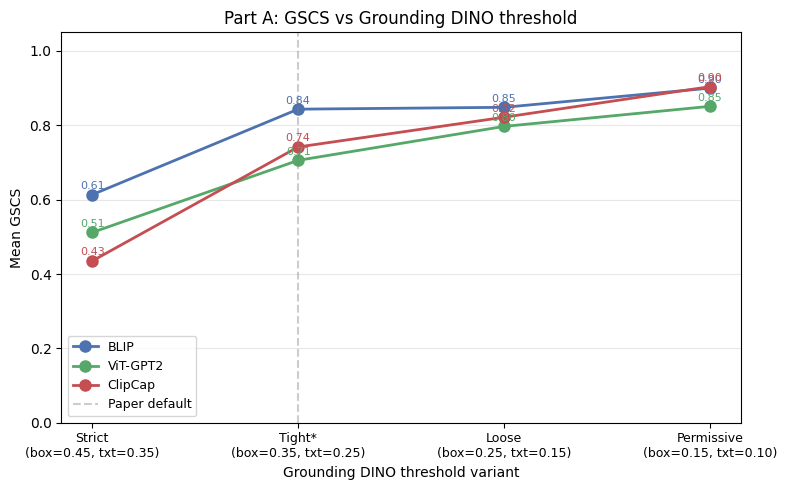

In [9]:
# Plot mean GSCS vs threshold variant, one line per model.

variant_order = [v[0] for v in THRESHOLD_VARIANTS]
model_colors = {"BLIP": "#4C72B0", "ViT-GPT2": "#55A868", "ClipCap": "#C44E52"}

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(variant_order))
for model_name in MODEL_CSV_PATHS:
    ys = [agg_A[(agg_A["model"] == model_name) & (agg_A["variant"] == v)]["GSCS"].iloc[0]
          for v in variant_order]
    ax.plot(x, ys, marker="o", linewidth=2, markersize=8,
            color=model_colors.get(model_name, "gray"), label=model_name)
    for xi, yi in zip(x, ys):
        ax.text(xi, yi + 0.015, f"{yi:.2f}", ha="center", fontsize=8,
                color=model_colors.get(model_name, "gray"))

ax.set_xticks(x)
ax.set_xticklabels([f"{v}\n(box={t:.2f}, txt={tt:.2f})"
                    for v, t, tt in THRESHOLD_VARIANTS], fontsize=9)
ax.axvline(variant_order.index("Tight*"), color="gray", linestyle="--", alpha=0.4,
           label="Paper default")
ax.set_ylabel("Mean GSCS")
ax.set_xlabel("Grounding DINO threshold variant")
ax.set_title("Part A: GSCS vs Grounding DINO threshold")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ablation_A_threshold_curves.png"),
            dpi=200, bbox_inches="tight")
plt.show()

In [10]:
# Spearman correlation: per-image GSCS at default vs other variants.

def _per_image_gscs(df, model, variant):
    sub = df[(df["model"] == model) & (df["variant"] == variant)].copy()
    return sub.sort_values("image")["gscs"].values

corr_rows = []
for model_name in MODEL_CSV_PATHS:
    base = _per_image_gscs(part_a_df, model_name, "Tight*")
    for vname, _, _ in THRESHOLD_VARIANTS:
        if vname == "Tight*":
            continue
        other = _per_image_gscs(part_a_df, model_name, vname)
        mask = ~(np.isnan(base) | np.isnan(other))
        if mask.sum() > 1 and np.std(base[mask]) > 0 and np.std(other[mask]) > 0:
            rho, p = spearmanr(base[mask], other[mask])
        else:
            rho, p = float("nan"), float("nan")
        corr_rows.append({
            "model": model_name,
            "variant_vs_Tight*": vname,
            "spearman_rho": rho,
            "p_value": p,
            "n": int(mask.sum()),
        })

corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv(os.path.join(RESULTS_DIR, "partA_spearman_vs_default.csv"), index=False)
print("Spearman rank correlation of per-image GSCS vs paper-default (Tight*):")
corr_df

Spearman rank correlation of per-image GSCS vs paper-default (Tight*):


,model,variant_vs_Tight*,spearman_rho,p_value,n
0,BLIP,Strict,0.508708,1.618576e-04,50
1,BLIP,Loose,0.596212,4.908522e-06,50
2,BLIP,Permissive,0.436121,1.545570e-03,50
3,ViT-GPT2,Strict,0.800931,2.875578e-12,50
4,ViT-GPT2,Loose,0.662466,1.603539e-07,50
5,ViT-GPT2,Permissive,0.620340,1.547046e-06,50
6,ClipCap,Strict,0.494846,2.590739e-04,50
7,ClipCap,Loose,0.732410,1.492728e-09,50
8,ClipCap,Permissive,0.439717,1.397817e-03,50


In [11]:
# Part B: noun-extractor swap (NLTK vs spaCy vs naive regex).

rows_B = []

for _, row in tqdm(captions_df.iterrows(), total=len(captions_df), desc="Part B (extractor swap)"):
    for extractor_name, extractor_fn in EXTRACTORS.items():
        caption_objects = extractor_fn(row["caption"])

        if not caption_objects:
            rows_B.append({
                "model": row["model"], "image": row["image"], "extractor": extractor_name,
                "object_count": 0, "grounded_count": 0, "gscs": 1.0,
            })
            continue

        try:
            outputs, input_ids, hw = gdino_forward(row["image_path"], caption_objects)
            detected = gdino_postprocess(outputs, input_ids, hw,
                                         DEFAULT_THRESHOLD, DEFAULT_TEXT_THRESHOLD)
            gscs, correct, n = gscs_from_sets(caption_objects, detected)
            rows_B.append({
                "model": row["model"], "image": row["image"], "extractor": extractor_name,
                "object_count": n, "grounded_count": correct, "gscs": gscs,
            })
        except Exception as e:
            rows_B.append({
                "model": row["model"], "image": row["image"], "extractor": extractor_name,
                "object_count": len(caption_objects), "grounded_count": 0,
                "gscs": np.nan, "error": str(e),
            })

part_b_df = pd.DataFrame(rows_B)
part_b_df.to_csv(os.path.join(RESULTS_DIR, "partB_extractor_swap_per_image.csv"), index=False)

agg_B = (part_b_df.groupby(["model", "extractor"])
                  .agg(GSCS=("gscs", "mean"),
                       mean_object_count=("object_count", "mean"),
                       n=("gscs", "count"))
                  .reset_index())
agg_B.to_csv(os.path.join(RESULTS_DIR, "partB_extractor_swap_summary.csv"), index=False)
agg_B

Part B (extractor swap):   0%|          | 0/150 [00:00<?, ?it/s]

,model,extractor,GSCS,mean_object_count,n
0,BLIP,NLTK*,0.843333,2.42,50
1,BLIP,Naive,0.453000,3.72,50
2,BLIP,spaCy,0.836667,2.40,50
3,ClipCap,NLTK*,0.741667,1.64,50
4,ClipCap,Naive,0.306048,3.22,50
5,ClipCap,spaCy,0.715667,1.70,50
6,ViT-GPT2,NLTK*,0.705667,3.04,50
7,ViT-GPT2,Naive,0.329667,4.76,50
8,ViT-GPT2,spaCy,0.709000,3.04,50


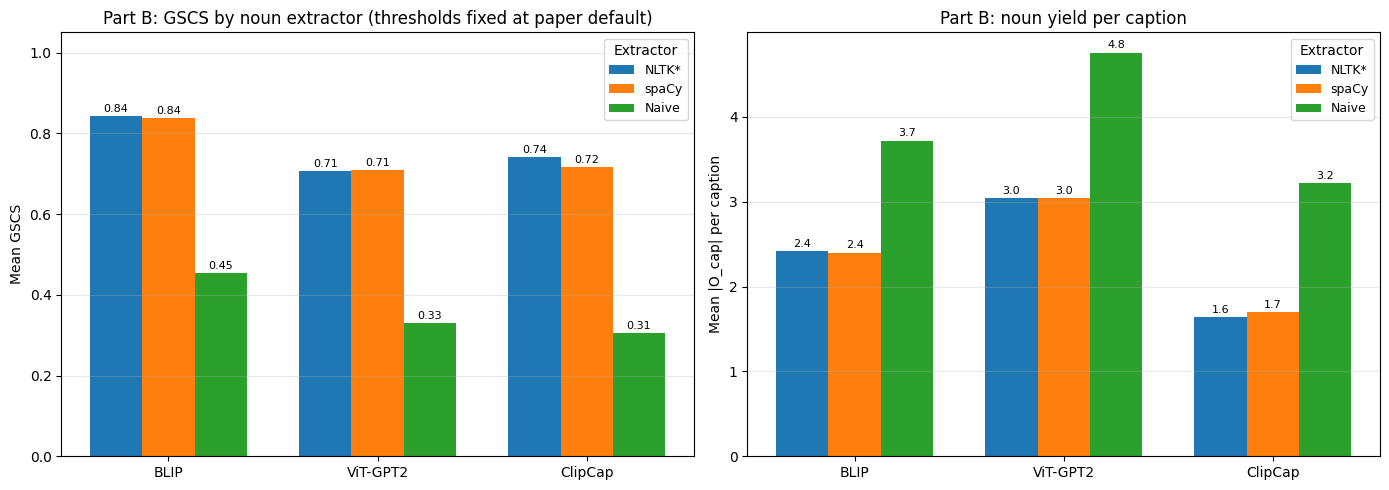

In [12]:
extractor_order = list(EXTRACTORS.keys())
model_order = list(MODEL_CSV_PATHS.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: mean GSCS per (model, extractor).
ax = axes[0]
x = np.arange(len(model_order))
width = 0.25
for i, ext in enumerate(extractor_order):
    ys = [agg_B[(agg_B["model"] == m) & (agg_B["extractor"] == ext)]["GSCS"].iloc[0]
          for m in model_order]
    bars = ax.bar(x + (i - 1) * width, ys, width, label=ext)
    for xi, yi in zip(x + (i - 1) * width, ys):
        ax.text(xi, yi + 0.01, f"{yi:.2f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(model_order)
ax.set_ylabel("Mean GSCS")
ax.set_ylim(0, 1.05)
ax.set_title("Part B: GSCS by noun extractor (thresholds fixed at paper default)")
ax.legend(title="Extractor", fontsize=9)
ax.grid(axis="y", alpha=0.3)

# Right panel: mean |O_cap| per (model, extractor).
ax = axes[1]
for i, ext in enumerate(extractor_order):
    ys = [agg_B[(agg_B["model"] == m) & (agg_B["extractor"] == ext)]["mean_object_count"].iloc[0]
          for m in model_order]
    ax.bar(x + (i - 1) * width, ys, width, label=ext)
    for xi, yi in zip(x + (i - 1) * width, ys):
        ax.text(xi, yi + 0.05, f"{yi:.1f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(model_order)
ax.set_ylabel("Mean |O_cap| per caption")
ax.set_title("Part B: noun yield per caption")
ax.legend(title="Extractor", fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ablation_B_extractor_swap.png"),
            dpi=200, bbox_inches="tight")
plt.show()

In [13]:
# Part C: IGNORE_WORDS filter on vs off.

rows_C = []

for _, row in tqdm(captions_df.iterrows(), total=len(captions_df), desc="Part C (ignore-list)"):
    for variant_name, ignore_set in [("with_ignore*", IGNORE_WORDS), ("no_ignore", set())]:
        caption_objects = extract_nltk(row["caption"], ignore=ignore_set)

        if not caption_objects:
            rows_C.append({
                "model": row["model"], "image": row["image"], "variant": variant_name,
                "object_count": 0, "grounded_count": 0, "gscs": 1.0,
            })
            continue

        try:
            outputs, input_ids, hw = gdino_forward(row["image_path"], caption_objects)
            detected = gdino_postprocess(outputs, input_ids, hw,
                                         DEFAULT_THRESHOLD, DEFAULT_TEXT_THRESHOLD)
            gscs, correct, n = gscs_from_sets(caption_objects, detected)
            rows_C.append({
                "model": row["model"], "image": row["image"], "variant": variant_name,
                "object_count": n, "grounded_count": correct, "gscs": gscs,
            })
        except Exception as e:
            rows_C.append({
                "model": row["model"], "image": row["image"], "variant": variant_name,
                "object_count": len(caption_objects), "grounded_count": 0,
                "gscs": np.nan, "error": str(e),
            })

part_c_df = pd.DataFrame(rows_C)
part_c_df.to_csv(os.path.join(RESULTS_DIR, "partC_ignore_list_per_image.csv"), index=False)

agg_C = (part_c_df.groupby(["model", "variant"])
                  .agg(GSCS=("gscs", "mean"),
                       mean_object_count=("object_count", "mean"))
                  .reset_index()
                  .pivot(index="model", columns="variant", values=["GSCS", "mean_object_count"]))
agg_C.columns = [f"{a}__{b}" for a, b in agg_C.columns]
agg_C["GSCS_delta_(on-off)"] = agg_C["GSCS__with_ignore*"] - agg_C["GSCS__no_ignore"]
agg_C = agg_C.reset_index()
agg_C.to_csv(os.path.join(RESULTS_DIR, "partC_ignore_list_summary.csv"), index=False)
agg_C

Part C (ignore-list):   0%|          | 0/150 [00:00<?, ?it/s]

,model,GSCS__no_ignore,GSCS__with_ignore*,mean_object_count__no_ignore,mean_object_count__with_ignore*,GSCS_delta_(on-off)
0,BLIP,0.816667,0.843333,2.46,2.42,0.026667
1,ClipCap,0.575000,0.741667,2.22,1.64,0.166667
2,ViT-GPT2,0.675667,0.705667,3.22,3.04,0.030000


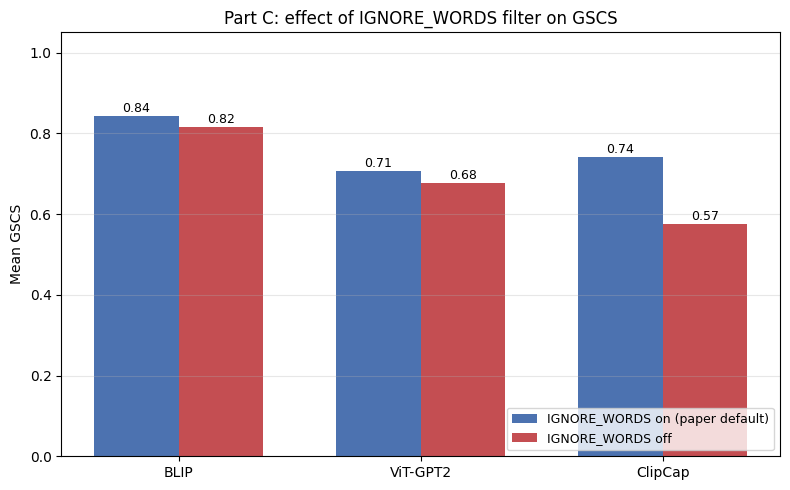

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(model_order))
width = 0.35

ys_on  = [agg_C[agg_C["model"] == m]["GSCS__with_ignore*"].iloc[0] for m in model_order]
ys_off = [agg_C[agg_C["model"] == m]["GSCS__no_ignore"].iloc[0]    for m in model_order]

b1 = ax.bar(x - width/2, ys_on,  width, label="IGNORE_WORDS on (paper default)",  color="#4C72B0")
b2 = ax.bar(x + width/2, ys_off, width, label="IGNORE_WORDS off",                 color="#C44E52")

for xi, yi in zip(x - width/2, ys_on):
    ax.text(xi, yi + 0.01, f"{yi:.2f}", ha="center", fontsize=9)
for xi, yi in zip(x + width/2, ys_off):
    ax.text(xi, yi + 0.01, f"{yi:.2f}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_order)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mean GSCS")
ax.set_title("Part C: effect of IGNORE_WORDS filter on GSCS")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ablation_C_ignore_list.png"),
            dpi=200, bbox_inches="tight")
plt.show()

In [15]:
# Consolidated summary: model ranking under each variant.
ranking_rows = []
for vname, _, _ in THRESHOLD_VARIANTS:
    sub = agg_A[agg_A["variant"] == vname].set_index("model")["GSCS"]
    order = sub.sort_values(ascending=False).index.tolist()
    ranking_rows.append({"variant": vname, "ranking_high_to_low": " > ".join(order),
                         **{m: round(float(sub.loc[m]), 4) for m in model_order}})

ranking_df = pd.DataFrame(ranking_rows)
ranking_df.to_csv(os.path.join(RESULTS_DIR, "partA_ranking_by_variant.csv"), index=False)

print("=== GSCS ranking under each threshold variant ===")
print(ranking_df.to_string(index=False))

print("\n=== GSCS ranking under each extractor (paper-default thresholds) ===")
for ext in extractor_order:
    sub = agg_B[agg_B["extractor"] == ext].set_index("model")["GSCS"]
    order = sub.sort_values(ascending=False).index.tolist()
    print(f"  {ext:7s}: {' > '.join(order)}  "
          + "  ".join(f"[{m}={sub.loc[m]:.3f}]" for m in model_order))

print("\n=== GSCS ranking with/without IGNORE_WORDS ===")
for vcol in ["GSCS__with_ignore*", "GSCS__no_ignore"]:
    sub = agg_C.set_index("model")[vcol]
    order = sub.sort_values(ascending=False).index.tolist()
    print(f"  {vcol:22s}: {' > '.join(order)}  "
          + "  ".join(f"[{m}={sub.loc[m]:.3f}]" for m in model_order))

=== GSCS ranking under each threshold variant ===
   variant       ranking_high_to_low   BLIP  ViT-GPT2  ClipCap
    Strict BLIP > ViT-GPT2 > ClipCap 0.6133    0.5117   0.4350
    Tight* BLIP > ClipCap > ViT-GPT2 0.8433    0.7057   0.7417
     Loose BLIP > ClipCap > ViT-GPT2 0.8483    0.7970   0.8217
Permissive ClipCap > BLIP > ViT-GPT2 0.9000    0.8510   0.9040

=== GSCS ranking under each extractor (paper-default thresholds) ===
  NLTK*  : BLIP > ClipCap > ViT-GPT2  [BLIP=0.843]  [ViT-GPT2=0.706]  [ClipCap=0.742]
  spaCy  : BLIP > ClipCap > ViT-GPT2  [BLIP=0.837]  [ViT-GPT2=0.709]  [ClipCap=0.716]
  Naive  : BLIP > ViT-GPT2 > ClipCap  [BLIP=0.453]  [ViT-GPT2=0.330]  [ClipCap=0.306]

=== GSCS ranking with/without IGNORE_WORDS ===
  GSCS__with_ignore*    : BLIP > ClipCap > ViT-GPT2  [BLIP=0.843]  [ViT-GPT2=0.706]  [ClipCap=0.742]
  GSCS__no_ignore       : BLIP > ViT-GPT2 > ClipCap  [BLIP=0.817]  [ViT-GPT2=0.676]  [ClipCap=0.575]


In [16]:
zip_path = os.path.join(OUTPUTS_DIR, "ablation_outputs.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for folder in (RESULTS_DIR, FIGURES_DIR):
        for root, _, files in os.walk(folder):
            for name in files:
                full = os.path.join(root, name)
                zf.write(full, os.path.relpath(full, BASE_DIR))

print("Saved figures to:", FIGURES_DIR)
print("Saved CSVs to:   ", RESULTS_DIR)
print("Archive:         ", zip_path)

Saved figures to: c:\Users\William\Desktop\Vision2Text\Vision2Text\outputs\project_ablation\figures
Saved CSVs to:    c:\Users\William\Desktop\Vision2Text\Vision2Text\outputs\project_ablation\results
Archive:          c:\Users\William\Desktop\Vision2Text\Vision2Text\outputs\ablation_outputs.zip
